In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings(ignore)

In [5]:
df=pd.read_csv(r"C:\Users\malay\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [10]:
df.sample()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2140,3023-GFLBR,Female,0,Yes,Yes,33,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Credit card (automatic),86.15,2745.7,Yes


In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [14]:
df.shape

(7043, 21)

In [16]:
# 2. Data Cleaning
# Convert TotalCharges to numeric, replacing empty spaces or errors with NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [18]:
# Fill missing TotalCharges with MonthlyCharges * tenure for consistency
df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [19]:
# Create a numeric column for Churn (1 for Yes, 0 for No) for easy aggregation
df["Churn_Num"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

In [20]:
# 3. Overall Churn Metrics
total_customers = len(df)
churned_customers = df["Churn_Num"].sum()
overall_churn_rate = df["Churn_Num"].mean() * 100

print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%\n")

Total Customers: 7043
Churned Customers: 1869
Overall Churn Rate: 26.54%



In [21]:
# 4. Churn Analysis by Key Dimensions
dimensions = [
    "Contract",
    "PaymentMethod",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
    "SeniorCitizen",
]

for col in dimensions:
    print(f"--- Churn Analysis by {col} ---")
    summary = df.groupby(col)["Churn_Num"].agg(
        Total_Customers="count",
        Churn_Rate=lambda x: f"{x.mean() * 100:.2f}%",
        Raw_Mean="mean",
    )
    print(summary)
    print("\n")

--- Churn Analysis by Contract ---
                Total_Customers Churn_Rate  Raw_Mean
Contract                                            
Month-to-month             3875     42.71%  0.427097
One year                   1473     11.27%  0.112695
Two year                   1695      2.83%  0.028319


--- Churn Analysis by PaymentMethod ---
                           Total_Customers Churn_Rate  Raw_Mean
PaymentMethod                                                  
Bank transfer (automatic)             1544     16.71%  0.167098
Credit card (automatic)               1522     15.24%  0.152431
Electronic check                      2365     45.29%  0.452854
Mailed check                          1612     19.11%  0.191067


--- Churn Analysis by InternetService ---
                 Total_Customers Churn_Rate  Raw_Mean
InternetService                                      
DSL                         2421     18.96%  0.189591
Fiber optic                 3096     41.89%  0.418928
No            

In [22]:
# 5. Financial & Tenure Statistics by Churn Status
print("--- Tenure Statistics by Churn Status (Months) ---")
print(df.groupby("Churn")["tenure"].agg(["mean", "median", "min", "max"]))
print("\n")

print("--- Monthly Charges by Churn Status ($) ---")
print(df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median"]))
print("\n")

--- Tenure Statistics by Churn Status (Months) ---
            mean  median  min  max
Churn                             
No     37.569965    38.0    0   72
Yes    17.979133    10.0    1   72


--- Monthly Charges by Churn Status ($) ---
            mean  median
Churn                   
No     61.265124  64.425
Yes    74.441332  79.650




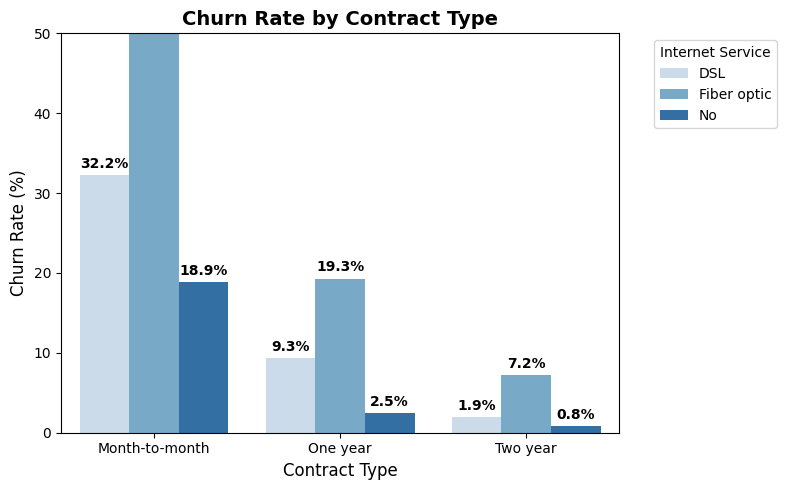

In [39]:

# 6. Optional: Generate & Save Visualization (Contract Churn Rate)
# Calculate churn rate by Contract and InternetService
import matplotlib.pyplot as plt
import seaborn as sns
contract_churn = (
    df.groupby(["Contract", "InternetService"])["Churn_Num"].mean().reset_index()
)
contract_churn["Churn_Rate"] = contract_churn["Churn_Num"] * 100

# Simple barplot with hue
plt.figure(figsize=(8, 5))
ax=sns.barplot(
    data=contract_churn,
    x="Contract",
    y="Churn_Rate",
    hue="InternetService",
    palette="Blues"
)

plt.title("Churn Rate by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.ylim(0, 50)
plt.legend(title="Internet Service", bbox_to_anchor=(1.05, 1), loc="upper left")

# ✅ Add labels to each bar automatically
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontweight="bold")
    
plt.tight_layout()
plt.savefig("churn_by_contract_hue.png", dpi=300)
plt.show()


C:\Users\malay\AppData\Local\Temp\ipykernel_44348\1997709349.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=labels, title="Churn Status", bbox_to_anchor=(1.05, 1), loc="upper left")


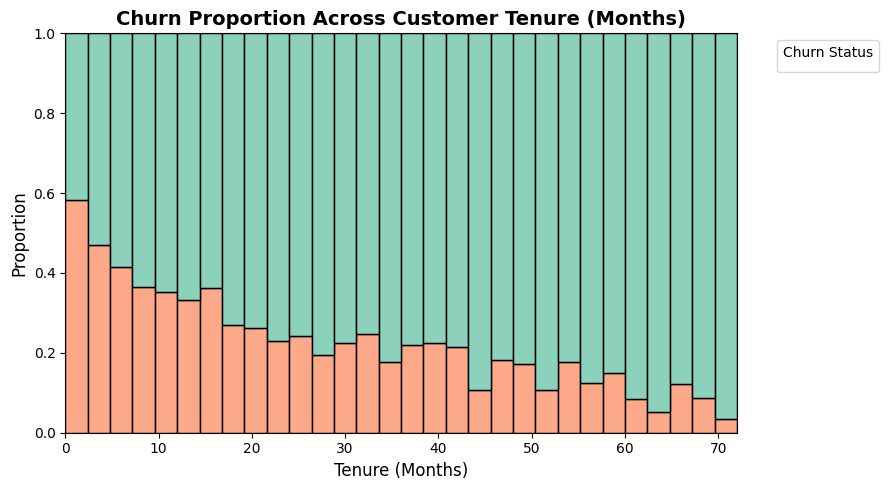

In [44]:
# --- VISUALIZATION 2: Tenure Distribution by Churn Status ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
ax = sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    multiple="fill",
    palette="Set2",
    bins=30,
    stat="proportion"
)

plt.title("Churn Proportion Across Customer Tenure (Months)", fontsize=14, fontweight="bold")
plt.xlabel("Tenure (Months)", fontsize=12)
plt.ylabel("Proportion", fontsize=12)

# ✅ Get handles and labels from the plot and pass them to legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title="Churn Status", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("churn_by_tenure_distribution.png", dpi=300)
plt.show()


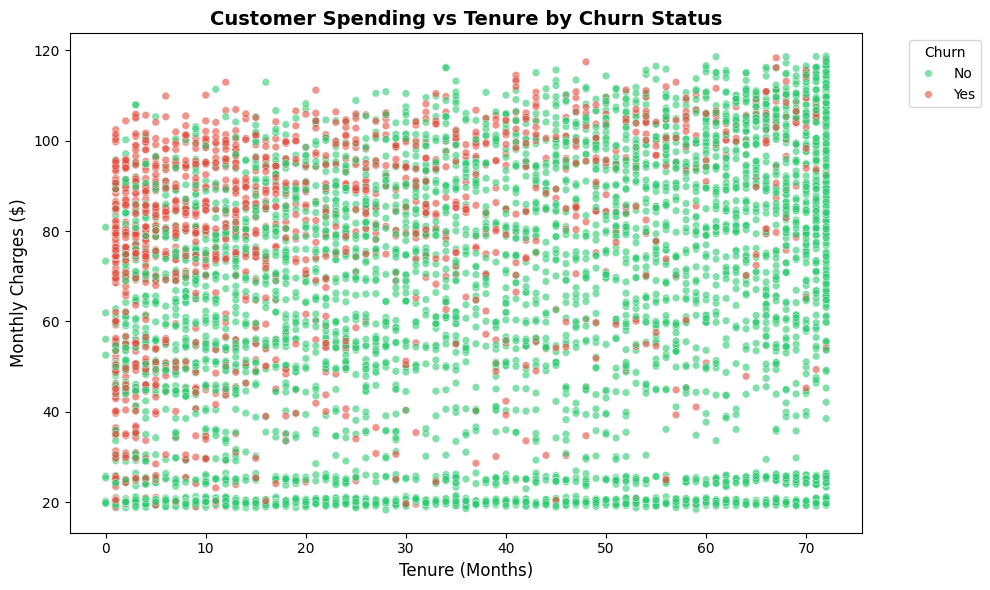

In [47]:
# --- VISUALIZATION 3: Monthly Charges vs Tenure (Scatter) ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6,
    palette={"No": "#2ecc71", "Yes": "#e74c3c"},
    s=30
)

plt.title("Customer Spending vs Tenure by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Tenure (Months)", fontsize=12)
plt.ylabel("Monthly Charges ($)", fontsize=12)

# ✅ Move legend outside for clarity
plt.legend(title="Churn", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("monthly_charges_vs_tenure.png", dpi=300)
plt.show()


In [50]:
# --- VISUALIZATION 4: Churn Rate by Internet Service & Payment Method ---


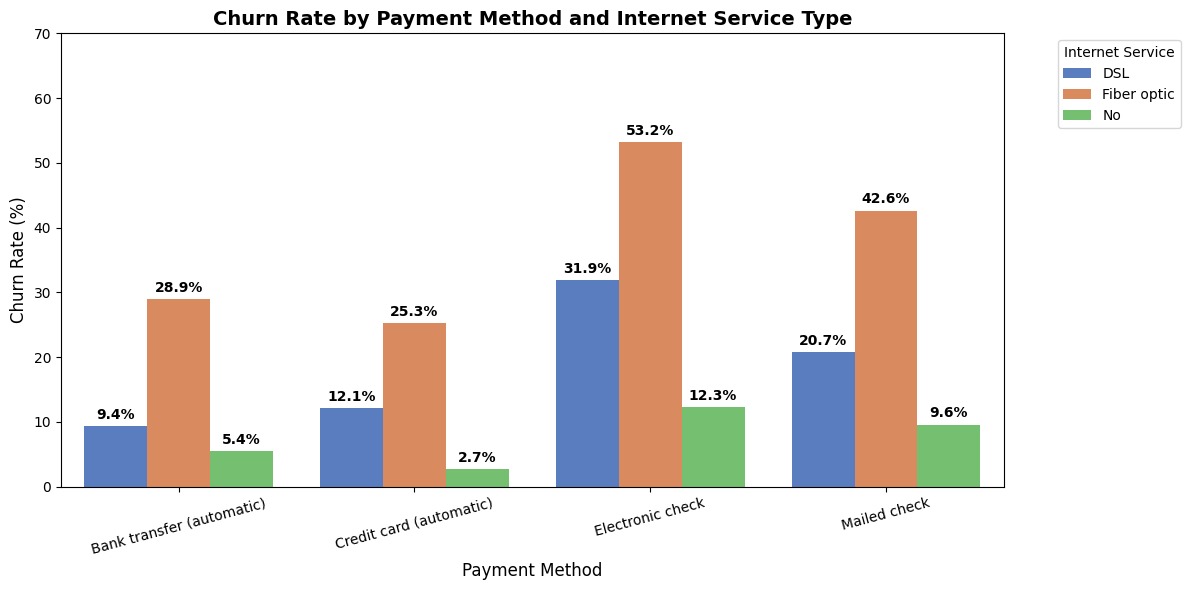

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
payment_internet = (
    df.groupby(["InternetService", "PaymentMethod"])["Churn_Num"]
    .mean()
    .reset_index()
)
payment_internet["Churn_Rate"] = payment_internet["Churn_Num"] * 100

ax4 = sns.barplot(
    data=payment_internet,
    x="PaymentMethod",
    y="Churn_Rate",
    hue="InternetService",
    palette="muted",
)

plt.title("Churn Rate by Payment Method and Internet Service Type", fontsize=14, fontweight="bold")
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0, 70)

# ✅ Add percentage labels to each bar
for container in ax4.containers:
    ax4.bar_label(container, fmt="%.1f%%", padding=3, fontweight="bold")

plt.legend(title="Internet Service", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("churn_payment_internet.png", dpi=300)
plt.show()


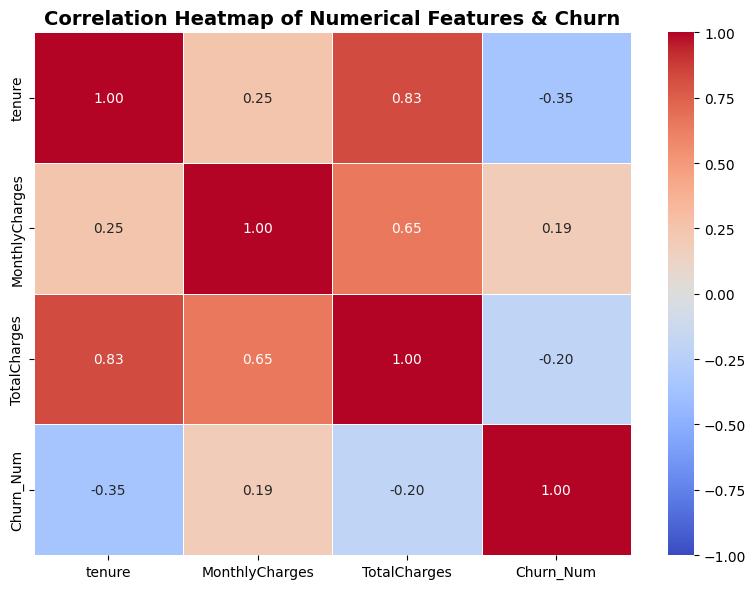

In [52]:
# --- VISUALIZATION 5: Correlation Matrix / Heatmap ---
plt.figure(figsize=(8, 6))
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_Num"]
corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)

plt.title("Correlation Heatmap of Numerical Features & Churn", fontsize=14, fontweight="bold")
plt.tight_layout()

# ✅ Save and show (don’t close immediately)
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()


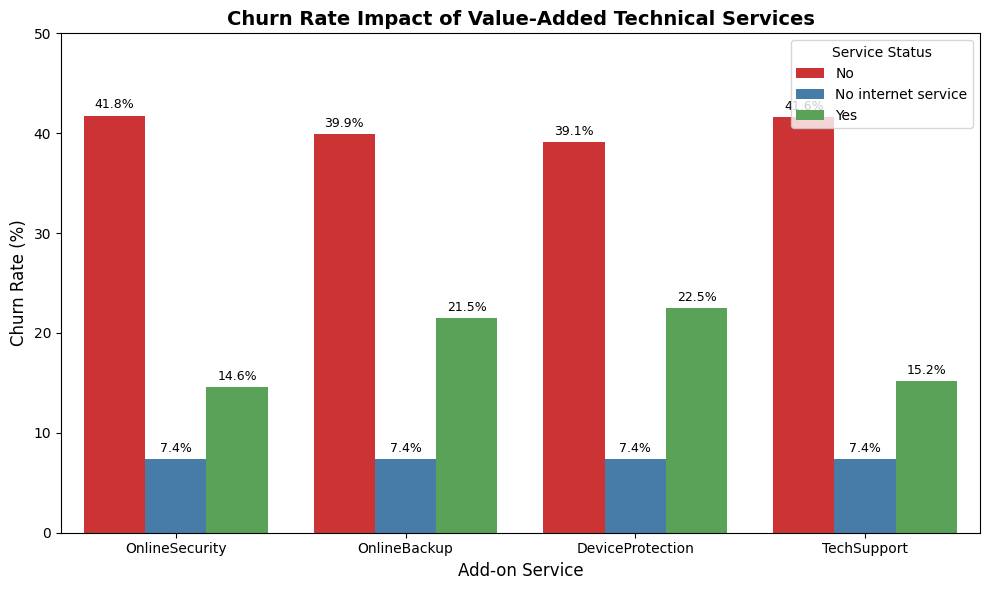

In [54]:
# --- VISUALIZATION 6: Churn Rate by Add-on Services ---
plt.figure(figsize=(10, 6))
addons = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]

addon_data = []
for addon in addons:
  temp = df.groupby(addon)["Churn_Num"].mean().reset_index()
  temp["Service"] = addon
  temp.rename(columns={addon: "Status", "Churn_Num": "Churn_Rate"}, inplace=True)
  addon_data.append(temp)

addon_df = pd.concat(addon_data, ignore_index=True)
addon_df["Churn_Rate"] = addon_df["Churn_Rate"] * 100

ax6 = sns.barplot(
    data=addon_df,
    x="Service",
    y="Churn_Rate",
    hue="Status",
    palette="Set1",
)
plt.title(
    "Churn Rate Impact of Value-Added Technical Services",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Add-on Service", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.legend(title="Service Status", loc="upper right")
plt.ylim(0, 50)

for p in ax6.patches:
  height = p.get_height()
  if height > 0:
    ax6.annotate(
        f"{height:.1f}%",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("churn_by_addons.png", dpi=300)
plt.show()

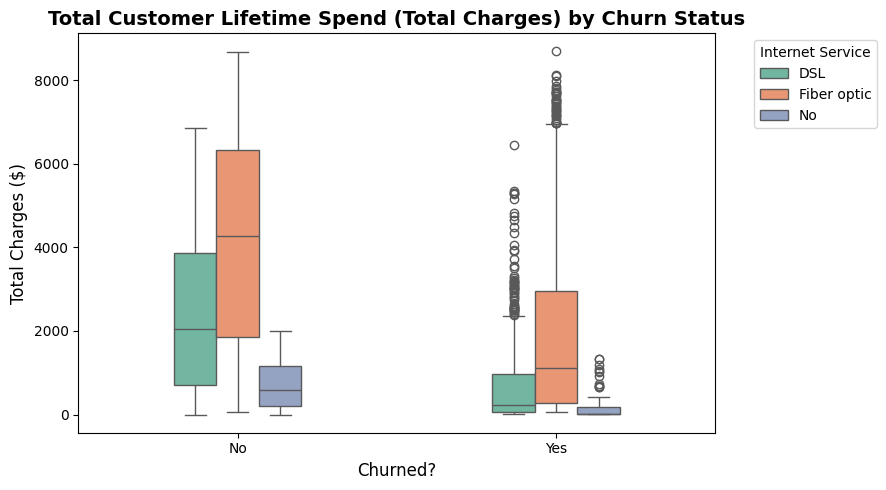

In [57]:
# --- VISUALIZATION 7: Total Charges (CLV Proxy) Distribution by Churn ---
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges",
    hue="InternetService",
    palette="Set2",
    width=0.4,
)
plt.title(
    "Total Customer Lifetime Spend (Total Charges) by Churn Status",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Churned?", fontsize=12)
plt.ylabel("Total Charges ($)", fontsize=12)
plt.legend(title="Internet Service", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("total_charges_boxplot.png", dpi=300)
plt.show()